In [144]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load Data
df_songs = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/songs_fact.csv", index_col=0)
df_metrics = pd.read_csv("C:/fiifi/Shatta_Analytics_Project/Python_files/python_data_analysis/platform_metrics_dim.csv", index_col=0)

In [145]:
# Filter df_metrics for only YouTube
df_youtube = df_metrics[df_metrics["platform_name"] == "YouTube"].copy()

In [146]:
# Merge df_songs and df_youtube
df_merged = df_songs.merge(df_youtube, on="song_id", how="inner")

# Drop release_date_original and release_date_original.1
df_merged = df_merged.drop(columns=["release_date_original", "release_date_original.1"])

In [147]:
# Convert release_date  to datetime
df_merged["release_date"] = pd.to_datetime(df_merged["release_date"], dayfirst=False, errors="coerce")

In [148]:
# Calculate song age in days(as of current date/ reference date)
reference_date = datetime.now()
df_merged["song_age_days"] = (reference_date - df_merged["release_date"]).dt.days

In [149]:
# Remove songs with invalid release dates or negative age
df_merged = df_merged[df_merged["song_age_days"] >= 0].copy()

In [151]:
# Create age brackets
def assign_age_bracket(days):   # Assign a song to an age bracket based on its age in days
    if days <= 7:
        return "1-7 days (Launch Week)"
    elif days <= 30:
        return "8-30 days (Momentum Period)"
    elif days <= 90:
        return "31-90 days (Stabilization)"
    else:
        return "90+ days (Long Tail)"

# Apply the function to create a new column
df_merged["age_bracket"] = df_merged["song_age_days"].apply(assign_age_bracket)

In [152]:
# Calculate Average Views by Age Bracket
age_brac_stats = df_merged.groupby("age_bracket")["views"].agg(["mean", "median", "count"]).round(0)

In [153]:
# Order age_brackets correctly 
bracket_order = ["1-7 days (Launch Week)", "8-30 days (Momentum Period)", "31-90 days (Stabilization)", "90+ days (Long Tail)"]
age_brac_stats = age_brac_stats.reindex(bracket_order)

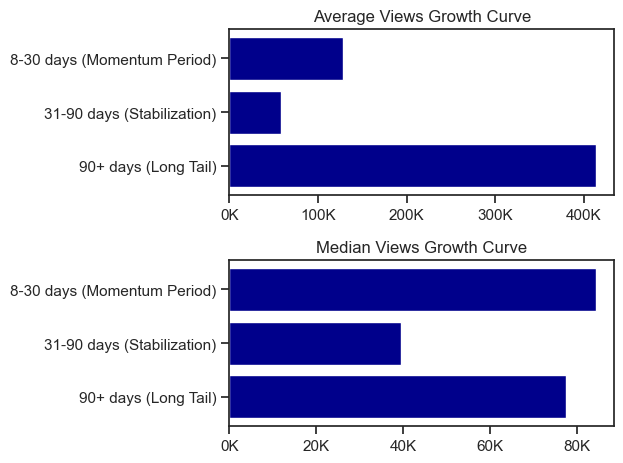

In [132]:
# Plot data
fig, ax = plt.subplots(2, 1)

# Set theme
sns.set_theme(style="ticks")

# Mean (Average Views) by age bracket
# sns.barplot(data=age_brac_stats, x="mean", y=age_brac_stats.index, ax=ax[0], hue="mean", palette="dark:b_r", legend=False)
mean_plot = ax[0].barh(age_brac_stats.index, age_brac_stats["mean"], color='darkblue')
ax[0].set_title("Average Views Growth Curve")
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].invert_yaxis()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))
# ax[0].set_yticklabels(age_brac_stats.index)

# Median (Median Views) by age bracket
# sns.barplot(data=age_brac_stats, x="median", y=age_brac_stats.index, ax=ax[1], hue="median", palette="dark:b_r", legend=False)
median_plot = ax[1].barh(age_brac_stats.index, age_brac_stats["median"], color='darkblue')
ax[1].set_title("Median Views Growth Curve")
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].invert_yaxis()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{int(x/1000)}K"))
# ax[1].set_yticklabels(age_brac_stats.index)

fig.tight_layout()
plt.show()


Insights:
Average Views Growth Curve (Mean)
- Average views grow steadily from 10K in first week → 100K by 30 days → 400K+ after 90 days
- The largest percentage increase happens in the first 30 days (10x growth from week 1)
- Long-term songs average 40x more views than first-week songs

Median Views Growth Curve
- Median views peak at 80K during days 8-30, then decline to 70K and 60K
- Most songs never grow after 30 days — they actually lose momentum
- The gap between mean (400K) and median (60K) at 90+ days proves only a few hit songs drive the average up

Recommendations
- Promote aggressively in first 30 days only — median views peak here and decline after, so extra promotion beyond 30 days has diminishing returns
- Don't expect most songs to become evergreen — the median line dropping tells you only 20-30% of songs will sustain long-term growth
- Use median (not mean) for realistic expectations — the mean is misleadingly high because a few outliers dominate; base decisions on what happens to a "typical" song